# Análisis Inicial

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Configuraciones adicionales

In [2]:
# Configuramos que se muestren todas las columnas de nuestros dataframes
pd.set_option('display.max_columns', None)

## Dataset 1:  **bank-additional**

### Contexto columnas:

- `age`: La edad del cliente.
- `job`: La ocupación o profesión del cliente.
- `marital`: El estado civil del cliente.
- `education`: El nivel educativo del cliente.
- `default`: Indica si el cliente tiene algún historial de incumplimiento de pagos (1: Sí, 0: No).
- `housing`: Indica si el cliente tiene un préstamo hipotecario (1: Sí, 0: No).
- `loan`: Indica si el cliente tiene algún otro tipo de préstamo (1: Sí, 0: No).
- `contact`: El método de contacto utilizado para comunicarse con el cliente.
- `duration`: La duración en segundos de la última interacción con el cliente.
- `campaign`: El número de contactos realizados durante esta campaña para este cliente.
- `pdays`: Número de días que han pasado desde la última vez que se contactó con el cliente durante esta campaña.
- `previous`: Número de veces que se ha contactado con el cliente antes de esta campaña.
- `poutcome`: Resultado de la campaña de marketing anterior.
- `emp.var.rate`: La tasa de variación del empleo.
- `cons.price.idx`: El índice de precios al consumidor.
- `cons.conf.idx`: El índice de confianza del consumidor.
- `euribor3m`: La tasa de interés de referencia a tres meses.
- `nr.employed`: El número de empleados.
- `y`: Indica si el cliente ha suscrito un producto o servicio (Sí/No).
- `date`: La fecha en la que se realizó la interacción con el cliente.
- `contact_month`: Mes en el que se realizó la interacción con el cliente durante la campaña de marketing.
- `contact_year`: Año en el que se realizó la interacción con el cliente durante la campaña de marketing.
- `id_`: Un identificador único para cada registro en el dataset.

### Apretura y primer análisis del DF

In [3]:
df_bank = pd.read_csv('files/input/bank-additional.csv')

In [6]:
#  Mostramos el dataframe
df_bank.sample(3)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
3044,3141,31.0,technician,MARRIED,professional.course,0.0,1.0,0.0,telephone,374,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,86",5191,no,7-junio-2016,27.515,-90.350,9a4398c6-059e-4194-8946-eb3767220d56
37605,37772,66.0,retired,MARRIED,university.degree,0.0,0.0,1.0,cellular,315,1,999,0,NONEXISTENT,-2.9,"92,201","-31,4","0,843","5076,2",no,30-septiembre-2015,32.043,-113.608,0eec281b-020b-45d9-b883-b4033423f878
15328,15425,30.0,admin.,MARRIED,university.degree,0.0,0.0,0.0,cellular,483,1,999,0,NONEXISTENT,1.4,"93,918","-42,7","4,957","5228,1",no,11-enero-2019,40.296,-91.918,c74d29a4-6c92-4e36-96e3-9b77789baf94


In [5]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

#### **Observaciones** y **Ajustes** preeliminares

- Columna ` Unnamed: 0` innecesaria.
- Nombres de varias columnas con un formato poco optimo (ej. separación con puntos)
- Columnas con tipos incorrectos:
    - `age` -->  es float, debería ser integer
    - `cons.price.idx`, `cons.conf.idx` , ` euribor3m` y ` nr.employed` --> son strings y deberían ser float
        - El error está en que los decimales están separados por **coma** en vez de por **punto**
    - `date` --> String y debería ser fecha
    - `default, `housing` y `loan` --> son floats pero en realidad son variables categoricas (Sí o no), asi decididmos cambiar los numeros por texto y convertirlas a formato string (0:No, 1, Yes)
- En el dataset no apartecen ni `contact_month` ni `contact_year`, pero se puede acceder a esa información a partir de `date`.

##### Ajustes iniciales

###### Eliminar columna Unnamed

In [7]:
# Eliminamos la columna 'Unnamed: 0'
df_bank = df_bank.drop(columns='Unnamed: 0')

# Y revisamos que se ha eliminado correctamente
df_bank.sample(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
13037,31.0,services,MARRIED,basic.9y,0.0,0.0,0.0,cellular,679,1,999,0,NONEXISTENT,1.4,"93,918","-42,7",NaN,"5228,1",yes,11-abril-2017,48.603,-120.273,a4ee1c2b-bf4f-444c-9f93-d4b7c54b46de
16524,23.0,admin.,SINGLE,professional.course,0.0,1.0,0.0,cellular,902,2,999,0,NONEXISTENT,1.4,"93,918","-42,7","4,963","5228,1",yes,24-abril-2015,29.666,-78.810,53b4e747-7fb0-42b2-aead-74967be17ad5


###### Formatear nombres de las columnas
- Para ello creamos una función que podamos reutiliza en la carpeta **scr** en el archivo **formatting_utils**

In [8]:
# Importamos la funcion
from scr.formatting_utils import column_names_formatting

In [9]:
# Ejecutamos la funcion en el dataframe
df_bank = column_names_formatting(df_bank)

In [10]:
# Comprobamos que los ajustes se han realizado correctamente
df_bank.sample(2)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,LATITUDE,LONGITUDE,ID
7767,35.0,blue-collar,MARRIED,high.school,0.0,0.0,0.0,telephone,184,1,999,0,NONEXISTENT,1.4,"94,465","-41,8","4,865","5228,1",no,1-noviembre-2015,40.678,-117.465,107439e8-f853-4627-b87e-2ed177a37a2e
37848,69.0,retired,MARRIED,basic.9y,0.0,1.0,0.0,cellular,71,1,5,1,SUCCESS,-3.4,"92,379","-29,8","0,781","5017,5",no,24-junio-2017,47.639,-76.371,b7fcf650-fb86-4599-8bdb-bf7aaa0978f0


###### Ajuste tipo de datos de las columnas

In [11]:
# Cambiamos el tipo de `age` a integer
# df_bank['AGE'] = df_bank['AGE'].astype("'Int64'")

In [12]:
# En las columnas numericas con decimales separados por comas, hacemos el cambio a puntos
to_float_columns = ['CONSPRICEIDX', 'CONSCONFIDX', 'EURIBOR3M', 'NREMPLOYED']

df_bank[to_float_columns] = df_bank[to_float_columns].apply(lambda x: x.str.replace(",","."))

In [13]:
# Comprobamos que el cambio se ha realizado correctamente
df_bank[to_float_columns].sample(2)

,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED
13852,93.918,-42.7,4.963,5228.1
25555,93.2,-42,4.12,5195.8


In [14]:
# Cambiamos el tipo de las columnas a float
df_bank[to_float_columns] = df_bank[to_float_columns].astype("float64")

In [15]:
# Ajustamos el tipo de la columna 'DATE' a tipo fecha

# Como los nombres de los meses están en español, primero tenemos que cambiarlos a inglés para poder hacer el ajuste
# Diccionario de meses español → inglés
meses = {
    "enero": "january", "febrero": "february", "marzo": "march", "abril": "april",
    "mayo": "may", "junio": "june", "julio": "july", "agosto": "august",
    "septiembre": "september", "octubre": "october", "noviembre": "november", "diciembre": "december"
}

# Reemplazamos los meses en las columna
for es,en in meses.items():
    df_bank["DATE"] = df_bank["DATE"].replace(es,en,regex=True)


# Cambiamos el el tipo de dato a fecha
df_bank["DATE"] = pd.to_datetime(df_bank["DATE"], format="%d-%B-%Y")

In [16]:
# Comprobamos que el ajuste se ha realizado correctamente
df_bank["DATE"].sample(3)

41339   2018-03-05
12632   2016-01-18
2258    2019-05-08
Name: DATE, dtype: datetime64[ns]

In [17]:
# Ajustamos las columnas `default, `housing` y `loan` 

# Seleccionamos las columnas
bool_cols = ['DEFAULT', 'HOUSING', 'LOAN']

# Construimos el mapa con los valores a intercambiar
yes_no = {0:'No', 1:'Yes'}

# Reemplazamos los valores en las columnas
for col in bool_cols:
    for n,s in yes_no.items():
        df_bank[col] = df_bank[col].replace(n,s,regex=True)

In [18]:
# Y comprobamos que todos los tipos se han ajustado correctamente
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   AGE           37880 non-null  float64       
 1   JOB           42655 non-null  object        
 2   MARITAL       42915 non-null  object        
 3   EDUCATION     41193 non-null  object        
 4   DEFAULT       34019 non-null  object        
 5   HOUSING       41974 non-null  object        
 6   LOAN          41974 non-null  object        
 7   CONTACT       43000 non-null  object        
 8   DURATION      43000 non-null  int64         
 9   CAMPAIGN      43000 non-null  int64         
 10  PDAYS         43000 non-null  int64         
 11  PREVIOUS      43000 non-null  int64         
 12  POUTCOME      43000 non-null  object        
 13  EMPVARRATE    43000 non-null  float64       
 14  CONSPRICEIDX  42529 non-null  float64       
 15  CONSCONFIDX   43000 non-null  float6

#### Duplicados

In [19]:
# Comprobamos si tenemos lineas duplicadas en nuestro dataframe
df_bank.duplicated().sum()

np.int64(0)

No tenemos valores duplicados

#### Valores Nulos

Por el momento únicamente los vamos a identificar, no los vamos a gestionar.

Para facilitarnos la exploración creamos una funcion de análisis en la carpeta **scr**, fichero **explore_utils** llamado `null_analysis`

In [20]:
# importamos la funcion

from scr.explore_utils import null_analysis

In [21]:
nulos = null_analysis(df_bank).sort_values(by= 'NULL_PERCENT',ascending=False)

In [22]:
nulos[nulos['NULL_PERCENT'] > 0]

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
16,EURIBOR3M,33744,9256,21.53,float64
4,DEFAULT,34019,8981,20.89,object
0,AGE,37880,5120,11.91,float64
3,EDUCATION,41193,1807,4.20,object
5,HOUSING,41974,1026,2.39,object
6,LOAN,41974,1026,2.39,object
14,CONSPRICEIDX,42529,471,1.10,float64
1,JOB,42655,345,0.80,object
19,DATE,42752,248,0.58,datetime64[ns]
2,MARITAL,42915,85,0.20,object


##### Análisis de nulos
- Tenemos tres columnas con las de un 20% de valores nulos, un valor muy alto
    - `EURIBOR3M`
    -  `DEFAULT`
- Una columna con mas de un 10% de valores nulos, también un valor significativo aunque moderado
    - `AGE`
- Y el resto con un porcentaje de nulos que no supera el 5&
    - Destaca `EDUCATION`, el más cercano  ese 5%
    - Entre el 1& y el 3 % se encuentran `HOUSING`, `LOAN` y `CONSPRICEIDX`
    - Y tres no llegan ni al 1% de valores nulos:
        - `JOB`, `DATE` y `MARITAL`

> Para esta parte de análisis inicial por el momento no vamos a realizar una gestion de valores nulos, pero es importante tenerlos en cuenta en los analisis iniciales

#### Variables Numéricas

Las columnas latitud y longitud no nos aportan mucha información en realidad, así que las eliminamos.

In [23]:
df_bank = df_bank.drop(columns=['LATITUDE', 'LONGITUDE'])

In [24]:
# Creamos un sub-dataframe de columnas numericas
num_bank = df_bank.select_dtypes(include='number').columns

In [25]:
df_bank[num_bank].sample()

,AGE,DURATION,CAMPAIGN,PDAYS,PREVIOUS,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED
12556,36.0,333,5,999,0,1.4,93.918,-42.7,4.96,5228.1


In [26]:
df_bank[num_bank].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AGE,37880.0,39.98,10.44,17.00,32.00,38.00,47.00,98.00
DURATION,43000.0,257.74,258.67,0.00,102.00,179.00,319.00,4918.00
CAMPAIGN,43000.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
PDAYS,43000.0,962.33,187.26,0.00,999.00,999.00,999.00,999.00
PREVIOUS,43000.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00
EMPVARRATE,43000.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
CONSPRICEIDX,42529.0,93.57,0.58,92.20,93.08,93.75,93.99,94.77
CONSCONFIDX,43000.0,-40.51,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
EURIBOR3M,33744.0,3.62,1.74,0.63,1.34,4.86,4.96,5.04
NREMPLOYED,43000.0,5166.85,72.41,4963.60,5099.10,5191.00,5228.10,5228.10


##### Visualizaciones Iniciales

###### Histogramas

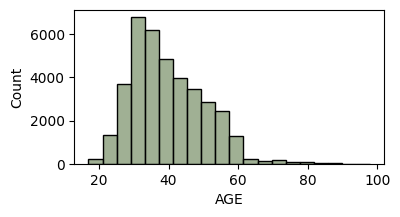

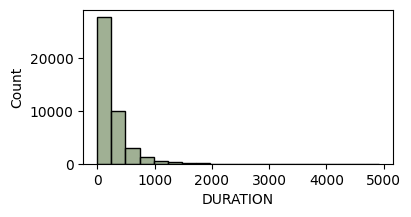

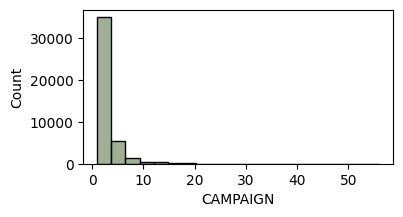

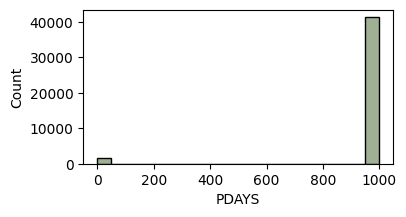

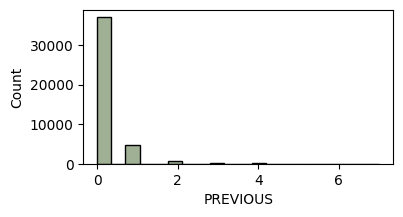

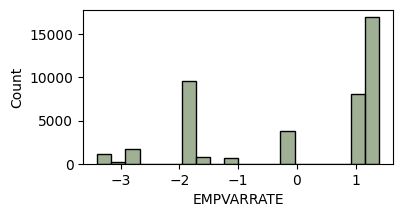

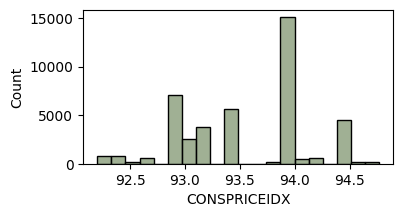

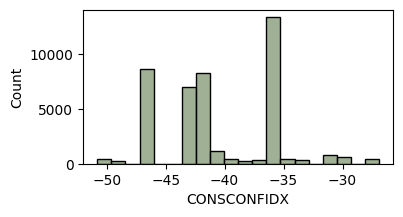

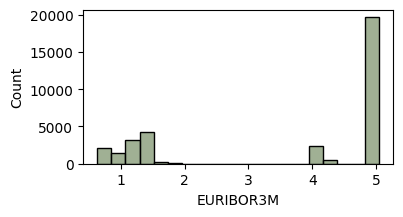

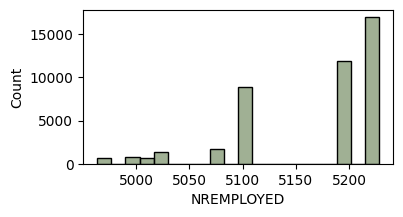

In [27]:
for col in num_bank:
    plt.figure(figsize=(4,2))

    sns.histplot(df_bank[col], bins=20, color='#809671')

    plt.show()

###### Boxplots

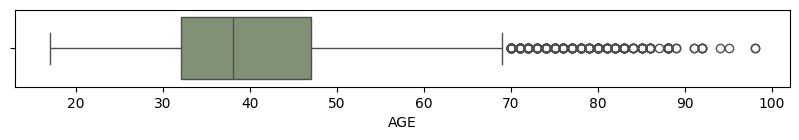

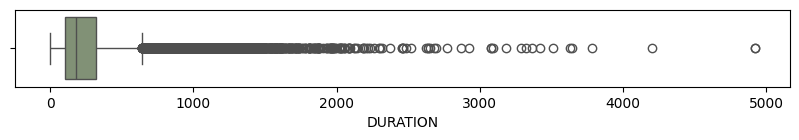

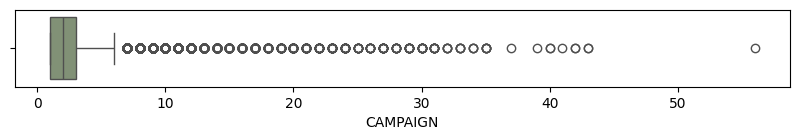

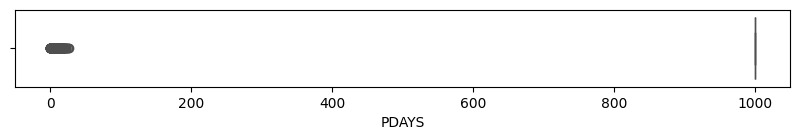

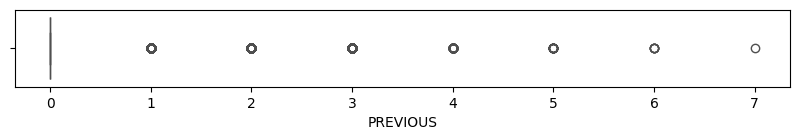

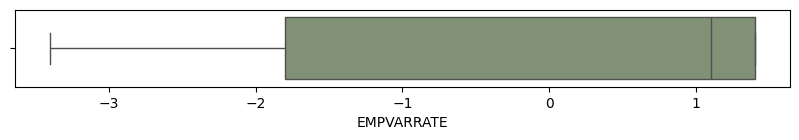

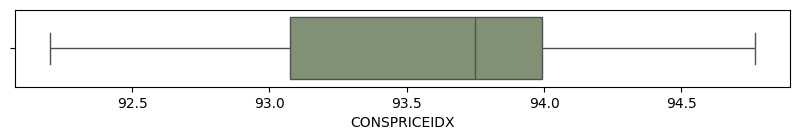

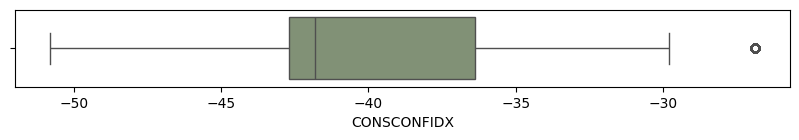

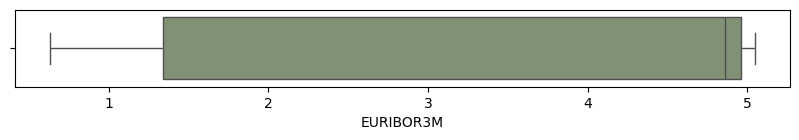

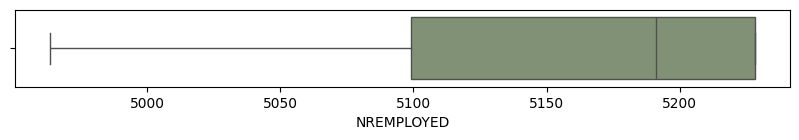

In [28]:
for col in num_bank:
    plt.figure(figsize=(10,1))

    sns.boxplot(x = df_bank[col], color='#809671')

    plt.show()

##### Observaciones 

###### Columnas:
- `AGE`:
    > La edad del cliente.
    
    - Análisis: La mayor parte de clientes se encuentra en un rango de edad entre los 32 y los 47 años, con algunos outliers a partir de los 70 años.
- `DURATION`:
    > La duración en segundos de la última interacción con el cliente.

    -Análisis: La mayor parte de las llamadas oscilan en duracion entre los 2 y los 5 minutos, pero algunas pueden alargarse hasta pasada la hora (outliers)
- `CAMPAIGN`:
    > El número de contactos realizados durante esta campaña para este cliente.

    - Análisis: En la mayor parte de los casos, a cada cliente se le contacta entre 1 y 3 veces. Muy pocas veces pasa de los 10 contactos pero hay un caso que llega a más de 50.
- `PDAYS`:
    > Número de días que han pasado desde la última vez que se contactó con el cliente durante esta campaña.

    - Análisis: Para la gran mayoría de los casos, la última vez que se contactói con los clientes fue hace más de dos años (+999 días que es el maximo reflejado). En muy pocos casos se ha contactado con el mismo cliente a los pocos dias. **COLUMNA MUY POCO INFORMATIVA, se valora eliminar**
- `PREVIOUS`:
    > Número de veces que se ha contactado con el cliente antes de esta campaña.

    - Análisis: En muy pocos casos se había contactado previamente con los clientes con anterioridad, siendo el máximo de veces 7.
- `EMPVARRATE`:
    > La tasa de variación del empleo.

    - Definición: indicador económico que mide el cambio porcentual en el número de personas empleadas durante un período de tiempo específico, comparado con un período anterior.

    - Análisis: Aunque la media y mediana indican una tendencia a una mejora a nivel laboral de la mayoría de usuarios, encontramos una elevada variabilidad (desviación típica) y casos de un empeoramiento más significativo que de mejora -- Más clientes han mejorado, pero el grado de mejora es más modesto, que el nivel de empeoramiento de aquellos que ven empeorada su situación laboral.

- `CONSPRICEIDX`:
    > El índice de precios al consumidor.

    - Definición:  evolución del nivel de precios de una canasta de bienes y servicios representativos del consumo de los hogares

    - Análisis: Los datos sugieren una elevada estabilidad de los precios, donde la variabilidad entre ellos es bastante baja (max: 95, min 92).
    
- `CONSCONFIDX`:
    > El índice de confianza del consumidor.

    - Análisis: Destaca el bajo indice de confianza generalizado (valores siempre negativos)
- `EURIBOR3M`:
    > La tasa de interés de referencia a tres meses.

    - Definición: precio al que los bancos se prestan euros entre sí por un período determinado. Es un "termómetro" del costo del dinero en Europa.

    - Análisis: Elevada variabilidad, encontramos focos en precios altos y bajos, pero no intermedios.

- `NREMPLOYED`:
    > El número de empleados.

    - Análisis:  El gurso de numero de empelados oscila entre los 5000 y los 5200, sin desviarse en exceso de esa cifra en ningún momento.


#### Variables Categóricas

#### Variables de Fecha

## Dataset 2:  **customer-details**

Tres hojas diferentes (una por año)

### Contexto columnas:
-	`Income`: Representa el ingreso anual del cliente en términos monetarios.
-	`Kidhome`: Indica el número de niños en el hogar del cliente.
-	`Teenhome`: Indica el número de adolescentes en el hogar del cliente.
-	`Dt_Customer`: Representa la fecha en que el cliente se convirtió en cliente de la empresa.
-	`NumWebVisitsMonth`: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.
-	`ID`: Identificador único del cliente.